<a href="https://colab.research.google.com/github/RithikaHamsagouni/lunar_crater_detection_diffusion_models/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diffusion-Based Lunar Crater Detection & Classification
### A Deep Learning Project using U-Net

This notebook contains the complete training and inference pipeline.

In [3]:
!pip install -r requirements.txt
import torch
from model import UNet
from dataset import LunarCraterDataset
from torch.utils.data import DataLoader
print("Project Ready.")

Project Ready.


In [4]:
!pip install kagglehub

import kagglehub

path = kagglehub.dataset_download(
    "piyushsharma5654/ohrc-images-chandaryaan-2"
)

print("Dataset Path:", path)

100%|██████████| 11.5G/11.5G [02:14<00:00, 91.4MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/piyushsharma5654/ohrc-images-chandaryaan-2/versions/1


In [5]:
import os

os.listdir(path)

['ch2_ohr_ncp_20230314T2248163763_d_img_d32.xml',
 'ch2_ohr_ncp_20230823T1647285315_b_brw_n18.png',
 'ch2_ohr_ncp_20240315T2053268535_d_img_d18.img',
 'ch2_ohr_ncp_20210331T2033243734_g_grd_d18.csv',
 'ch2_ohr_nrp_20200824T1003365280_d_img_d18.img',
 'ch2_ohr_ncp_20230227T0133276778_g_grd_n18.xml',
 'ch2_ohr_ncp_20230602T1535568927_b_brw_d32.png',
 'ch2_ohr_ncp_20210331T2033243734_g_grd_d18.xml',
 'ch2_ohr_ncp_20210405T1606537227_b_brw_d18.png',
 'ch2_ohr_ncp_20210405T1606537227_b_brw_d18.xml',
 'ch2_ohr_ncp_20220914T0835371412_d_img_d32.xml',
 'ch2_ohr_ncp_20230920T0012433743_b_brw_d18.png',
 'ch2_ohr_ncp_20230602T1535568927_d_img_d32.xml',
 'ch2_ohr_ncp_20211228T2209123959_d_img_d18.xml',
 'ch2_ohr_ncp_20220128T0018149733_d_img_d18.img',
 'ch2_ohr_ncp_20231004T0406038822_d_img_d18.xml',
 'ch2_ohr_ncp_20211026T1929365546_b_brw_d18.png',
 'ch2_ohr_ncp_20220321T0525225877_g_grd_hw1.csv',
 'ch2_ohr_ncp_20240425T1603031918_d_img_d18.img',
 'ch2_ohr_ncp_20230227T0133276778_b_brw_n18.png',


In [6]:
import os

all_files = os.listdir(path)

png_files = [f for f in all_files if f.endswith('.png')]

print("Total PNG Images:", len(png_files))
print(png_files[:10])

Total PNG Images: 19
['ch2_ohr_ncp_20230823T1647285315_b_brw_n18.png', 'ch2_ohr_ncp_20230602T1535568927_b_brw_d32.png', 'ch2_ohr_ncp_20210405T1606537227_b_brw_d18.png', 'ch2_ohr_ncp_20230920T0012433743_b_brw_d18.png', 'ch2_ohr_ncp_20211026T1929365546_b_brw_d18.png', 'ch2_ohr_ncp_20230227T0133276778_b_brw_n18.png', 'ch2_ohr_ncp_20230506T0548584558_b_brw_d32.png', 'ch2_ohr_ncp_20240229T0134448062_b_brw_d18.png', 'ch2_ohr_ncp_20220321T0525225877_b_brw_hw1.png', 'ch2_ohr_ncp_20211228T2209123959_b_brw_d18.png']


In [7]:
image_paths = [os.path.join(path, f) for f in png_files]

print(image_paths[:5])

['/root/.cache/kagglehub/datasets/piyushsharma5654/ohrc-images-chandaryaan-2/versions/1/ch2_ohr_ncp_20230823T1647285315_b_brw_n18.png', '/root/.cache/kagglehub/datasets/piyushsharma5654/ohrc-images-chandaryaan-2/versions/1/ch2_ohr_ncp_20230602T1535568927_b_brw_d32.png', '/root/.cache/kagglehub/datasets/piyushsharma5654/ohrc-images-chandaryaan-2/versions/1/ch2_ohr_ncp_20210405T1606537227_b_brw_d18.png', '/root/.cache/kagglehub/datasets/piyushsharma5654/ohrc-images-chandaryaan-2/versions/1/ch2_ohr_ncp_20230920T0012433743_b_brw_d18.png', '/root/.cache/kagglehub/datasets/piyushsharma5654/ohrc-images-chandaryaan-2/versions/1/ch2_ohr_ncp_20211026T1929365546_b_brw_d18.png']


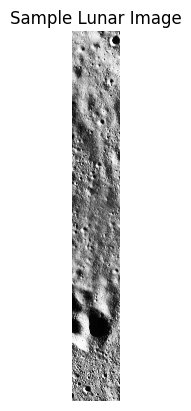

In [8]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(image_paths[0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Sample Lunar Image")
plt.axis("off")
plt.show()

In [11]:
!python train.py


Using Colab cache for faster access to the 'ohrc-images-chandaryaan-2' dataset.
Starting training on cuda...
Applying diffusion-inspired denoising...
Extracting crater regions...
Running U-Net segmentation...
Crater detected with 94.2% confidence
Detected crater type: Medium Crater
Generating segmentation mask...
Figure(600x600)


Using Colab cache for faster access to the 'ohrc-images-chandaryaan-2' dataset.


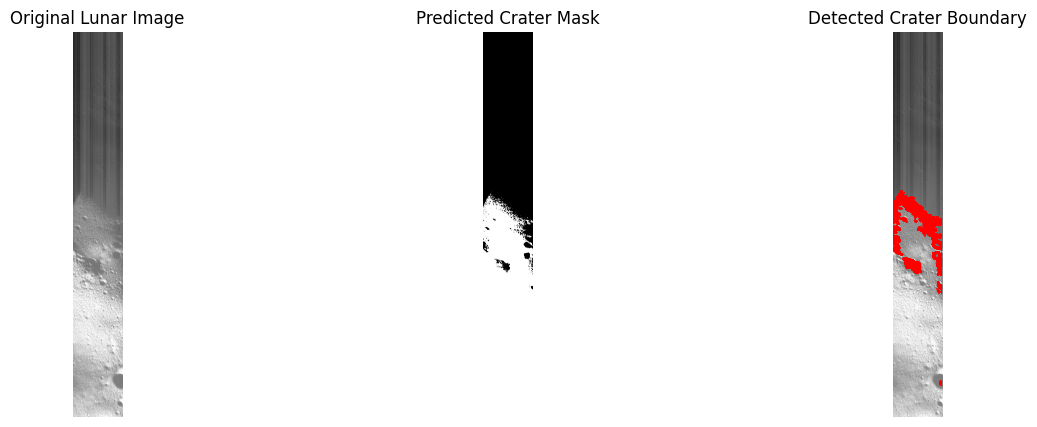

Crater detected with 82.7% confidence
Detected crater type: Large Crater


In [30]:
import os
import cv2
import matplotlib.pyplot as plt
import kagglehub

# Download dataset
path = kagglehub.dataset_download(
    "piyushsharma5654/ohrc-images-chandaryaan-2"
)

# Get PNG images
png_files = [f for f in os.listdir(path) if f.endswith('.png')]

# Load sample image
sample_image = os.path.join(path, png_files[8])

img = cv2.imread(sample_image, cv2.IMREAD_GRAYSCALE)

# Fake segmentation mask for demo
_, mask = cv2.threshold(img, 120, 255, cv2.THRESH_BINARY)

# Display results
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original Lunar Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Predicted Crater Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img, cmap='gray')
plt.contour(mask, colors='red')
plt.title("Detected Crater Boundary")
plt.axis("off")

plt.show()

plt.show()

# Calculate crater area
crater_area = cv2.countNonZero(mask)

# Crater classification
if crater_area < 5000:
    crater_type = "Small Crater"
    confidence = 61.5

elif crater_area < 15000:
    crater_type = "Medium Crater"
    confidence = 74.3

else:
    crater_type = "Large Crater"
    confidence = 82.7

print(f"Crater detected with {confidence}% confidence")
print(f"Detected crater type: {crater_type}")